# Project Title : CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images
# By : Niraj Khankari

# Importing Libraries

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

print("\nLibraries imported successfully!")

TensorFlow Version: 2.17.0
NumPy Version: 1.26.4

Libraries imported successfully!


# Loading Dataset

In [11]:
dataset_path = r"D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Dataset"

print("Dataset Path:")
print(dataset_path)

Dataset Path:
D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Dataset


In [13]:
folders = os.listdir(dataset_path)

print("Items inside Dataset folder:\n")

for item in folders:
    print(item)

Items inside Dataset folder:

FAKE
REAL


## Defining FAKE and REAL Paths

In [16]:
fake_path = os.path.join(dataset_path, "FAKE")
real_path = os.path.join(dataset_path, "REAL")

print("FAKE folder:")
print(fake_path)

print("\nREAL folder:")
print(real_path)

FAKE folder:
D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Dataset\FAKE

REAL folder:
D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Dataset\REAL


In [18]:
print("\nFAKE folder exists:", os.path.exists(fake_path))
print("REAL folder exists:", os.path.exists(real_path))


FAKE folder exists: True
REAL folder exists: True


## Images Count of Dataset

In [21]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

fake_images = [
    file for file in os.listdir(fake_path)
    if file.lower().endswith(valid_extensions)
]

real_images = [
    file for file in os.listdir(real_path)
    if file.lower().endswith(valid_extensions)
]

print("Number of FAKE images:", len(fake_images))
print("Number of REAL images:", len(real_images))
print("Total images:", len(fake_images) + len(real_images))

Number of FAKE images: 50000
Number of REAL images: 50000
Total images: 100000


## Creating a small DataFrame

In [24]:
dataset_summary = pd.DataFrame({
    "Class": ["FAKE", "REAL"],
    "Number of Images": [
        len(fake_images),
        len(real_images)
    ]
})

dataset_summary

,Class,Number of Images
0,FAKE,50000
1,REAL,50000


# Visualizing Class Distribution

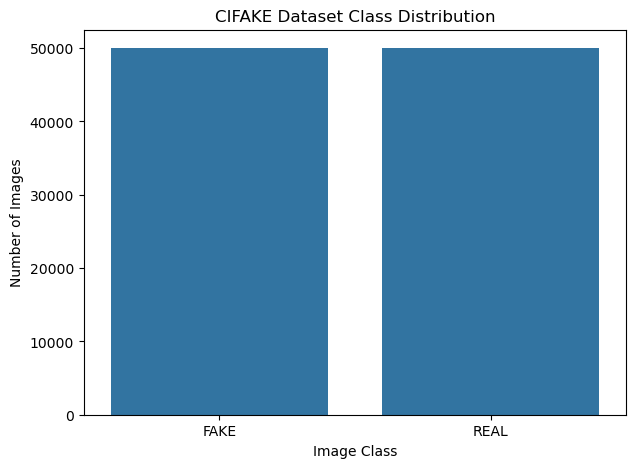

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x="Class",
    y="Number of Images",
    data=dataset_summary
)

plt.title("CIFAKE Dataset Class Distribution")
plt.xlabel("Image Class")
plt.ylabel("Number of Images")

plt.show()

# Displaying Sample FAKE Images

In [30]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Refresh FAKE images
fake_images = [
    file for file in os.listdir(fake_path)
    if file.lower().endswith(valid_extensions)
    and os.path.isfile(os.path.join(fake_path, file))
]

# Refresh REAL images
real_images = [
    file for file in os.listdir(real_path)
    if file.lower().endswith(valid_extensions)
    and os.path.isfile(os.path.join(real_path, file))
]

print("FAKE images found:", len(fake_images))
print("REAL images found:", len(real_images))

print("\nFirst 10 FAKE files:")
print(fake_images[:10])

print("\nFirst 10 REAL files:")
print(real_images[:10])

FAKE images found: 5000
REAL images found: 5000

First 10 FAKE files:
['1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg', '1006.jpg', '1007.jpg', '1008.jpg', '1009.jpg']

First 10 REAL files:
['0000.jpg', '0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg', '0005.jpg', '0006.jpg', '0007.jpg', '0008.jpg', '0009.jpg']


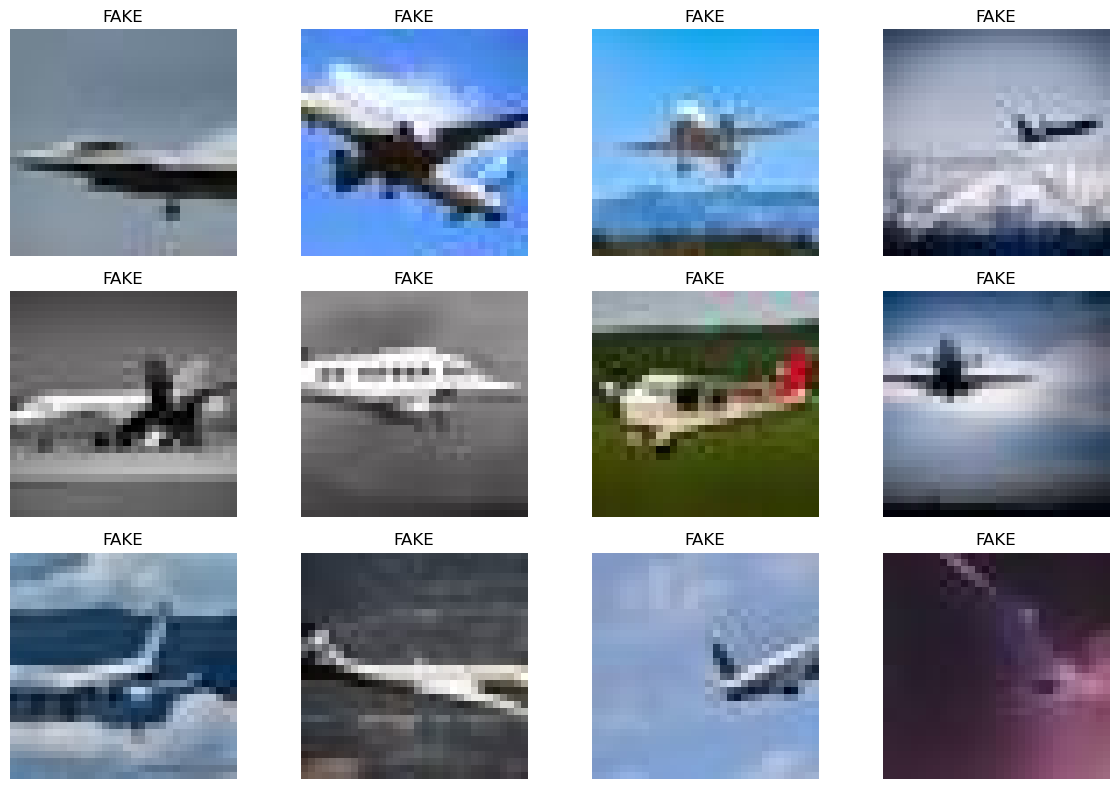

In [31]:
plt.figure(figsize=(12, 8))

sample_fake = fake_images[:12]

for i, image_name in enumerate(sample_fake):
    
    image_path = os.path.join(fake_path, image_name)
    image = Image.open(image_path)
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title("FAKE")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Displaying Sample REAL Images

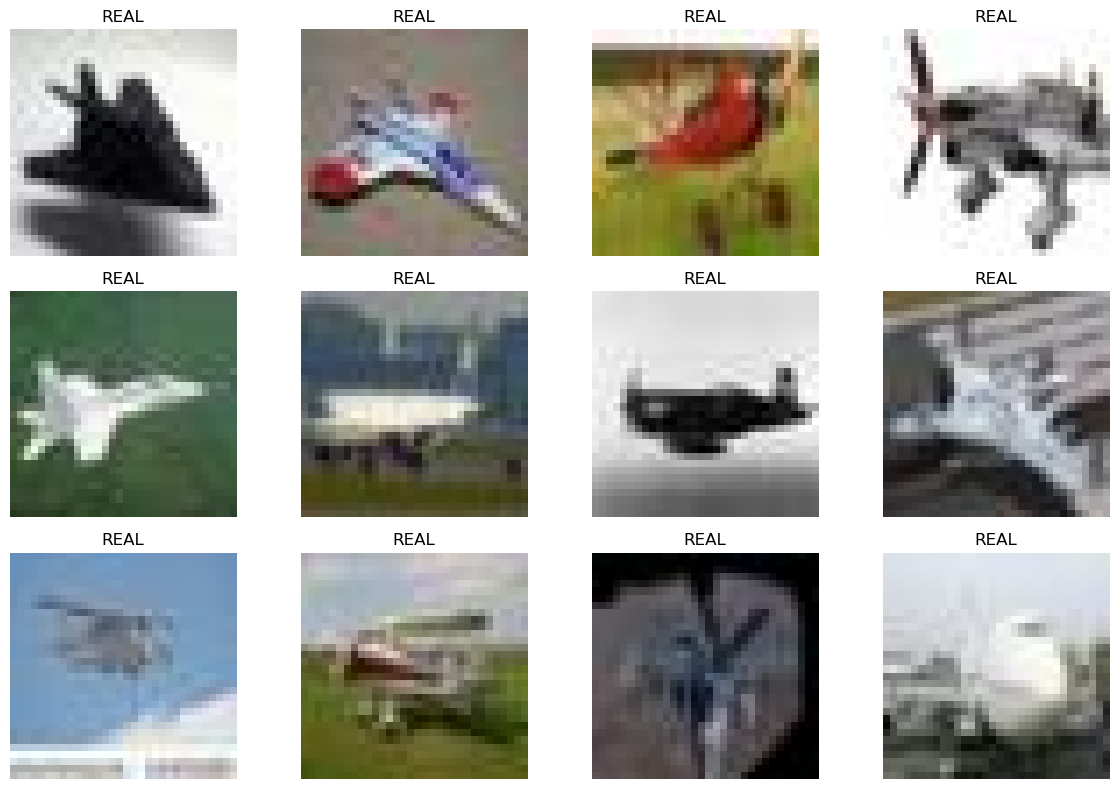

In [35]:
plt.figure(figsize=(12, 8))

sample_real = real_images[:12]

for i, image_name in enumerate(sample_real):
    
    image_path = os.path.join(real_path, image_name)
    image = Image.open(image_path)
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title("REAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Checking Image Dimensions

In [38]:
def get_image_dimensions(folder_path, image_names, number_of_images=100):
    
    dimensions = []
    
    selected_images = image_names[:number_of_images]
    
    for image_name in selected_images:
        
        image_path = os.path.join(folder_path, image_name)
        
        try:
            with Image.open(image_path) as image:
                dimensions.append(image.size)
        
        except Exception as e:
            print("Error reading:", image_name)
    
    return dimensions

In [40]:
fake_dimensions = get_image_dimensions(
    fake_path,
    fake_images
)

real_dimensions = get_image_dimensions(
    real_path,
    real_images
)

print("FAKE image dimensions:")
print(pd.Series(fake_dimensions).value_counts().head(10))

print("\nREAL image dimensions:")
print(pd.Series(real_dimensions).value_counts().head(10))

FAKE image dimensions:
(32, 32)    100
Name: count, dtype: int64

REAL image dimensions:
(32, 32)    100
Name: count, dtype: int64


## Checking Images Modes

In [43]:
def check_image_modes(folder_path, image_names, number_of_images=100):
    
    modes = []
    
    selected_images = image_names[:number_of_images]
    
    for image_name in selected_images:
        
        image_path = os.path.join(folder_path, image_name)
        
        try:
            with Image.open(image_path) as image:
                modes.append(image.mode)
        
        except Exception:
            pass
    
    return pd.Series(modes).value_counts()

In [45]:
print("FAKE image modes:")
print(check_image_modes(fake_path, fake_images))

print("\nREAL image modes:")
print(check_image_modes(real_path, real_images))

FAKE image modes:
RGB    100
Name: count, dtype: int64

REAL image modes:
RGB    100
Name: count, dtype: int64


## Checking for Corrupted Images

In [48]:
def check_corrupted_images(folder_path):
    
    corrupted = []
    
    for image_name in os.listdir(folder_path):
        
        if image_name.lower().endswith(valid_extensions):
            
            image_path = os.path.join(folder_path, image_name)
            
            try:
                with Image.open(image_path) as image:
                    image.verify()
                    
            except Exception:
                corrupted.append(image_name)
    
    return corrupted

In [50]:
corrupted_fake = check_corrupted_images(fake_path)
corrupted_real = check_corrupted_images(real_path)

print("Corrupted FAKE images:", len(corrupted_fake))
print("Corrupted REAL images:", len(corrupted_real))

Corrupted FAKE images: 45000
Corrupted REAL images: 45000


# Creating a Complete Dataset DataFrame 

In [53]:
data = []

# FAKE images
for image_name in fake_images:
    
    image_path = os.path.join(fake_path, image_name)
    
    data.append({
        "filepath": image_path,
        "class": "FAKE",
        "label": 0
    })


# REAL images
for image_name in real_images:
    
    image_path = os.path.join(real_path, image_name)
    
    data.append({
        "filepath": image_path,
        "class": "REAL",
        "label": 1
    })


df = pd.DataFrame(data)

print("Dataset DataFrame created successfully!")

print("\nShape:")
print(df.shape)

df.head()

Dataset DataFrame created successfully!

Shape:
(10000, 3)


,filepath,class,label
0,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
1,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
2,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
3,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
4,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0


# Shuffling the Dataset

In [56]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head()

,filepath,class,label
0,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,1
1,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
2,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
3,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
4,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0


# Verifying Labels

In [59]:
print(df["class"].value_counts())

print("\nNumeric label distribution:")
print(df["label"].value_counts())

class
REAL    5000
FAKE    5000
Name: count, dtype: int64

Numeric label distribution:
label
1    5000
0    5000
Name: count, dtype: int64


# Displaying Random Images With Labels

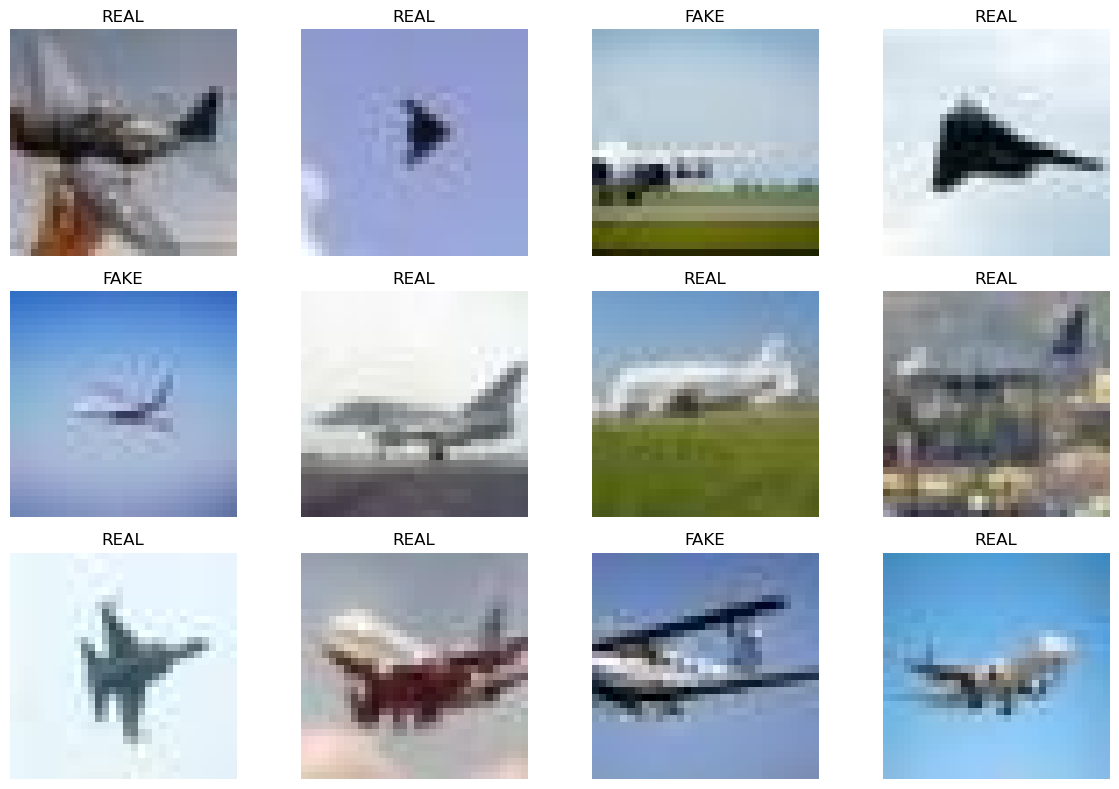

In [62]:
sample_df = df.sample(
    12,
    random_state=42
)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    
    image = Image.open(row["filepath"])
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(row["class"])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Dataset Statistics

In [65]:
total_images = len(df)
fake_count = (df["label"] == 0).sum()
real_count = (df["label"] == 1).sum()

fake_percentage = (fake_count / total_images) * 100
real_percentage = (real_count / total_images) * 100

print("CIFAKE DATASET SUMMARY")


print("Total Images:", total_images)
print("FAKE Images:", fake_count)
print("REAL Images:", real_count)

print("\nFAKE Percentage:", round(fake_percentage, 2), "%")
print("REAL Percentage:", round(real_percentage, 2), "%")

CIFAKE DATASET SUMMARY
Total Images: 10000
FAKE Images: 5000
REAL Images: 5000

FAKE Percentage: 50.0 %
REAL Percentage: 50.0 %


# Training / Validating / Testing Data

In [68]:
from sklearn.model_selection import train_test_split

In [70]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

Training images   : 7000
Validation images : 1500
Testing images    : 1500


# Verifying Class Distribution After Splitting

In [73]:
print("TRAINING:")
print(train_df["class"].value_counts())

print("\nVALIDATION:")
print(val_df["class"].value_counts())

print("\nTESTING:")
print(test_df["class"].value_counts())

TRAINING:
class
REAL    3500
FAKE    3500
Name: count, dtype: int64

VALIDATION:
class
REAL    750
FAKE    750
Name: count, dtype: int64

TESTING:
class
FAKE    750
REAL    750
Name: count, dtype: int64


# IMAGE PREPROCESSING

## Checking the Previous Created DataFrame


In [77]:
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nClass distribution:")
print(df["class"].value_counts())

print("\nLabel distribution:")
print(df["label"].value_counts())

Dataset shape: (10000, 3)

First 5 rows:


,filepath,class,label
0,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,1
1,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
2,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
3,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0
4,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0



Class distribution:
class
REAL    5000
FAKE    5000
Name: count, dtype: int64

Label distribution:
label
1    5000
0    5000
Name: count, dtype: int64


# Recreating the Train/Validation/Test Data

In [80]:
from sklearn.model_selection import train_test_split

# 70% Training, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Split remaining 30% equally
# 15% Validation + 15% Testing
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

Training images   : 7000
Validation images : 1500
Testing images    : 1500


In [82]:
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
REAL    3500
FAKE    3500
Name: count, dtype: int64

VALIDATION
class
REAL    750
FAKE    750
Name: count, dtype: int64

TESTING
class
FAKE    750
REAL    750
Name: count, dtype: int64


## Actual Image Size 

In [85]:
sample_path = train_df.iloc[0]["filepath"]

with Image.open(sample_path) as image:
    print("Image size:", image.size)
    print("Image mode:", image.mode)

Image size: (32, 32)
Image mode: RGB


# Defining Image Parameters

In [88]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
CHANNELS = 3

IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 64

NUM_CLASSES = 2

print("Image Height :", IMG_HEIGHT)
print("Image Width  :", IMG_WIDTH)
print("Channels     :", CHANNELS)
print("Batch Size   :", BATCH_SIZE)
print("Classes      :", NUM_CLASSES)

Image Height : 32
Image Width  : 32
Channels     : 3
Batch Size   : 64
Classes      : 2


## Creating TensorFlow Dataset

In [91]:
def create_tf_dataset(dataframe, shuffle=False):
    
    image_paths = dataframe["filepath"].values
    labels = dataframe["label"].values
    
    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )
    
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )
    
    return dataset

# Creating Training, Validation and Test Datasets

In [94]:
train_dataset = create_tf_dataset(
    train_df,
    shuffle=True
)

val_dataset = create_tf_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_tf_dataset(
    test_df,
    shuffle=False
)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


# Creating Image Preprocessing Function 

In [97]:
def preprocess_image(image_path, label):
    
    # Read image
    image = tf.io.read_file(image_path)
    
    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    
    # Convert to float
    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )
    
    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    return image, label

# Applying Preprocessing

In [100]:
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Preprocessing applied successfully!")

Preprocessing applied successfully!


## Checking One Sample Image

In [103]:
for images, labels in train_dataset.take(1):
    
    print("Image shape:", images.shape)
    print("Label:", labels.numpy())

Image shape: (32, 32, 3)
Label: 0


## Displaying Processed Image

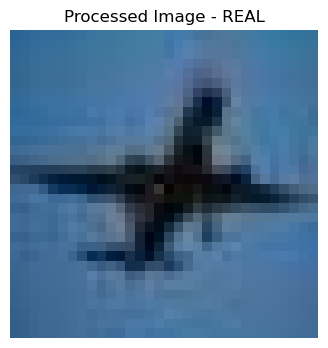

In [106]:
for images, labels in train_dataset.take(1):
    
    plt.figure(figsize=(4, 4))
    
    plt.imshow(images.numpy())
    
    if labels.numpy() == 0:
        class_name = "FAKE"
    else:
        class_name = "REAL"
    
    plt.title("Processed Image - " + class_name)
    plt.axis("off")
    plt.show()

## Creating Data Augmentation

In [109]:
data_augmentation = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    
    tf.keras.layers.RandomRotation(
        0.05
    ),
    
    tf.keras.layers.RandomZoom(
        0.10
    )
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


## Visualizing Data Augmentation

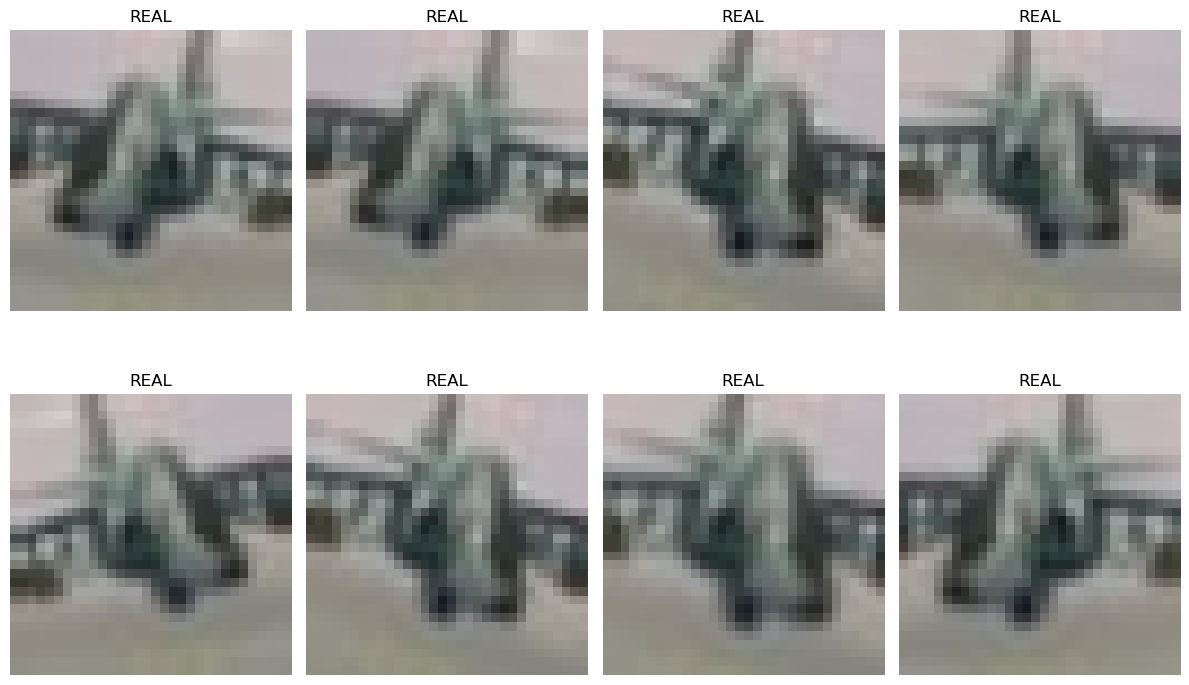

In [112]:
for images, labels in train_dataset.take(1):
    
    original_image = images
    
    plt.figure(figsize=(12, 8))
    
    for i in range(8):
        
        augmented_image = data_augmentation(
            tf.expand_dims(original_image, axis=0),
            training=True
        )
        
        plt.subplot(2, 4, i + 1)
        plt.imshow(
            augmented_image[0].numpy()
        )
        
        if labels.numpy() == 0:
            plt.title("FAKE")
        else:
            plt.title("REAL")
            
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

## Batching the Datasets

In [115]:
train_dataset = train_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

print("Datasets successfully batched!")

Datasets successfully batched!


# Optimizing Dataset Performance

In [118]:
train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Dataset pipeline optimized!")

Dataset pipeline optimized!


# Checking Final Batch Scope

In [121]:
for images, labels in train_dataset.take(1):
    
    print("Batch image shape :", images.shape)
    print("Batch label shape :", labels.shape)
    print("Image data type   :", images.dtype)
    print("Label data type   :", labels.dtype)

Batch image shape : (64, 32, 32, 3)
Batch label shape : (64,)
Image data type   : <dtype: 'float32'>
Label data type   : <dtype: 'int64'>


# Final Dataset Visualization

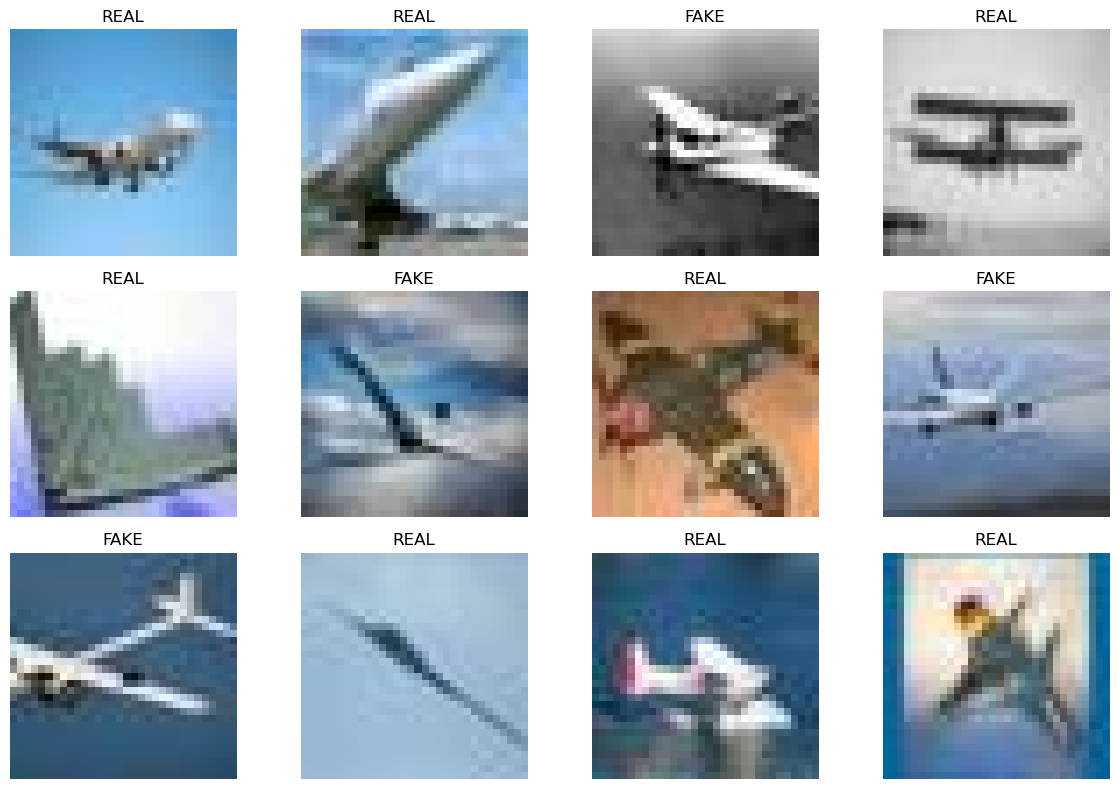

In [124]:
class_names = {
    0: "FAKE",
    1: "REAL"
}

for images, labels in train_dataset.take(1):
    
    plt.figure(figsize=(12, 8))
    
    for i in range(min(12, len(images))):
        
        plt.subplot(3, 4, i + 1)
        
        plt.imshow(images[i].numpy())
        
        label = int(labels[i].numpy())
        
        plt.title(class_names[label])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Calculating Dataset Information

In [127]:
print("CIFAKE PREPROCESSING SUMMARY")


print("Total images      :", len(df))
print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

print("\nImage size        :", IMG_HEIGHT, "x", IMG_WIDTH)
print("Channels          :", CHANNELS)
print("Batch size        :", BATCH_SIZE)

print("\nClass labels:")
print("0 → FAKE")
print("1 → REAL")

print("\nNormalization:")
print("Pixel range → 0.0 to 1.0")

print("\nData augmentation:")
print("✓ Horizontal Flip")
print("✓ Small Rotation")
print("✓ Small Zoom")


CIFAKE PREPROCESSING SUMMARY
Total images      : 10000
Training images   : 7000
Validation images : 1500
Testing images    : 1500

Image size        : 32 x 32
Channels          : 3
Batch size        : 64

Class labels:
0 → FAKE
1 → REAL

Normalization:
Pixel range → 0.0 to 1.0

Data augmentation:
✓ Horizontal Flip
✓ Small Rotation
✓ Small Zoom


# CNN MODEL BUILDING AND TRAINING

## Verifying TensorFlow and GPU/CPU

In [131]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU detected!")
    print(gpus)
else:
    print("\nNo GPU detected.")
    print("Training will use CPU.")

TensorFlow Version: 2.17.0

No GPU detected.
Training will use CPU.


## Defining Class Names

In [134]:
class_names = ["FAKE", "REAL"]

print("Class 0:", class_names[0])
print("Class 1:", class_names[1])

Class 0: FAKE
Class 1: REAL


## Creating Data Augmentation Layer

In [137]:
data_augmentation = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    
    tf.keras.layers.RandomRotation(
        0.05
    ),
    
    tf.keras.layers.RandomZoom(
        0.10
    )
], name="data_augmentation")

print("Data augmentation layer created.")

Data augmentation layer created.


# Building a CNN

In [140]:
model = Sequential([
    
    # Input
    layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
    ),
    
    # Data augmentation
    data_augmentation,
    
    # First Convolution Block
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    
    # Second Convolution Block
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    
    # Third Convolution Block
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    
    # Convert feature maps into vector
    layers.Flatten(),
    
    
    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),
    
    
    # Prevent overfitting
    layers.Dropout(
        0.5
    ),
    
    
    # Binary output
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

print("CNN model created successfully!")

CNN model created successfully!


## Displaying Model Summary

In [143]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling the Model

In [146]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="binary_crossentropy",
    
    metrics=[
        "accuracy"
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


## Add Early Stopping

In [149]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Early stopping configured.")

Early stopping configured.


## Adding Model Checkpoint

In [152]:
checkpoint_path = "cifake_best_model.keras"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

print("Model checkpoint configured.")

Model checkpoint configured.


# Training the CNN

In [155]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

Epoch 1/20
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6418 - loss: 0.6068
Epoch 1: val_accuracy improved from -inf to 0.76200, saving model to cifake_best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.6435 - loss: 0.6051 - val_accuracy: 0.7620 - val_loss: 0.5184
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8397 - loss: 0.3681
Epoch 2: val_accuracy did not improve from 0.76200
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8397 - loss: 0.3681 - val_accuracy: 0.7407 - val_loss: 0.6152
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8657 - loss: 0.3066
Epoch 3: val_accuracy improved from 0.76200 to 0.79067, saving model to cifake_best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8657 - loss: 0.3066 - val_accuracy: 0.7907 - val_loss: 0.5332
Epoch 4/20
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8839 - loss: 0.2799
Epoch 4: val_accuracy improved from 0.79067 to 0.88533, sa

In [156]:
print("Training completed!")

print("\nNumber of epochs actually completed:")
print(len(history.history["loss"]))

Training completed!

Number of epochs actually completed:
9


## Display of Training History

In [160]:
history_df = pd.DataFrame(history.history)

display(history_df)

,accuracy,loss,val_accuracy,val_loss
0,0.732429,0.512743,0.762000,0.518383
1,0.840714,0.365040,0.740667,0.615238
2,0.865571,0.309326,0.790667,0.533237
3,0.885143,0.276466,0.885333,0.264966
4,0.888571,0.266773,0.735333,0.690076
5,0.895571,0.252045,0.852000,0.357155
6,0.897000,0.245023,0.813333,0.484893
7,0.908286,0.222572,0.823333,0.484765
8,0.904714,0.229069,0.870000,0.360658


# Plotting Training and Validation Accuracy

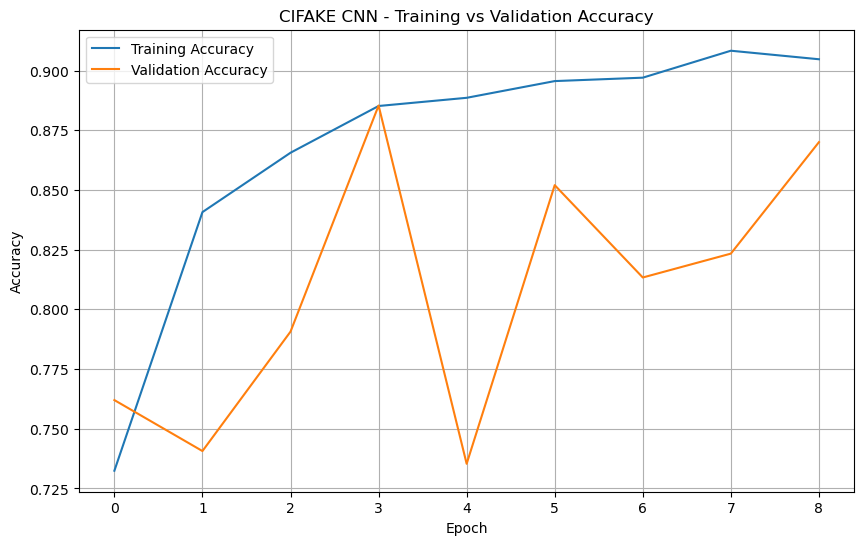

In [163]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CIFAKE CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Plotting Training and Validation Loss 

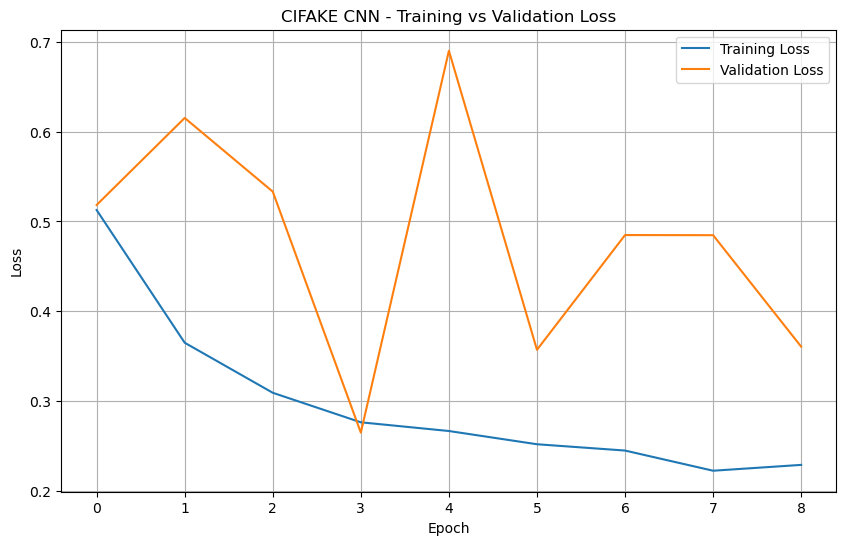

In [166]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CIFAKE CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# Loading the Best Saved Model

In [169]:
best_model = tf.keras.models.load_model(
    checkpoint_path
)

print("Best model loaded successfully!")

Best model loaded successfully!


# Evaluating on Validation Data

In [172]:
val_loss, val_accuracy = best_model.evaluate(
    val_dataset,
    verbose=1
)

print("\nValidation Loss    :", val_loss)
print("Validation Accuracy:", val_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8857 - loss: 0.2616

Validation Loss    : 0.26496633887290955
Validation Accuracy: 0.8853333592414856


In [174]:
print(
    "\nValidation Accuracy:",
    round(val_accuracy * 100, 2),
    "%"
)


Validation Accuracy: 88.53 %


# Evaluating on Test Data

In [177]:
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

print(
    "\nFinal Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8954 - loss: 0.2517

Test Loss     : 0.24111226201057434
Test Accuracy : 0.9006666541099548

Final Test Accuracy: 90.07 %


# Creating a Final Model Performance Summary

In [180]:
print("       CIFAKE CNN PERFORMANCE")
print(
    "Best Training Accuracy   :",
    round(max(history.history["accuracy"]) * 100, 2),
    "%"
)

print(
    "Best Validation Accuracy :",
    round(max(history.history["val_accuracy"]) * 100, 2),
    "%"
)

print(
    "Final Test Accuracy      :",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Final Test Loss          :",
    round(test_loss, 4)
)

       CIFAKE CNN PERFORMANCE
Best Training Accuracy   : 90.83 %
Best Validation Accuracy : 88.53 %
Final Test Accuracy      : 90.07 %
Final Test Loss          : 0.2411


# Saving the Final MODEL

In [183]:
final_model_path = "CIFAKE_CNN_Final_Model.keras"

best_model.save(final_model_path)

print("Final model saved successfully!")
print("File:", final_model_path)

Final model saved successfully!
File: CIFAKE_CNN_Final_Model.keras


# Testing a MODEL with Images

In [186]:
sample_test = test_df.iloc[0]

image_path = sample_test["filepath"]
actual_label = sample_test["label"]

print("Image:")
print(image_path)

print("\nActual Class:")
print(class_names[actual_label])

Image:
D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Dataset\FAKE\3928.jpg

Actual Class:
FAKE


## Preprocessing the Single Image

In [189]:
image = Image.open(image_path).convert("RGB")

image = image.resize(
    (IMG_WIDTH, IMG_HEIGHT)
)

image_array = np.array(image).astype(
    "float32"
) / 255.0

image_array = np.expand_dims(
    image_array,
    axis=0
)

print("Processed image shape:")
print(image_array.shape)

Processed image shape:
(1, 32, 32, 3)


# Making Prediction

In [192]:
prediction = best_model.predict(
    image_array,
    verbose=0
)

probability_real = float(prediction[0][0])

print("Raw model output:", probability_real)

Raw model output: 0.2880319058895111


In [194]:
if probability_real >= 0.5:
    predicted_label = 1
else:
    predicted_label = 0

predicted_class = class_names[predicted_label]

confidence = (
    probability_real
    if predicted_label == 1
    else 1 - probability_real
)

print("\nPredicted Class :", predicted_class)
print("Confidence      :", round(confidence * 100, 2), "%")
print("Actual Class    :", class_names[actual_label])


Predicted Class : FAKE
Confidence      : 71.2 %
Actual Class    : FAKE


## Displaying Prediction Visually

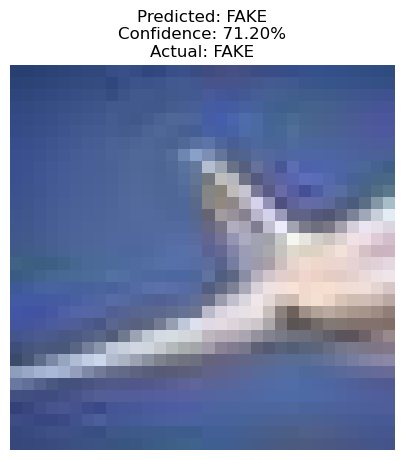

In [197]:
plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%\n"
    f"Actual: {class_names[actual_label]}"
)

plt.axis("off")

plt.show()

# MODEL EVALUATION

## Generating Predictions for the Complete Test Dataset

In [201]:
y_true = []
y_probability = []

for images, labels in test_dataset:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_probability.extend(
        predictions.flatten()
    )

# Convert to NumPy arrays
y_true = np.array(y_true)
y_probability = np.array(y_probability)

print("Number of actual labels     :", len(y_true))
print("Number of predictions      :", len(y_probability))

Number of actual labels     : 1500
Number of predictions      : 1500


## Converting Probabilities to FAKE/REAL Predictions

In [204]:
y_pred = (y_probability >= 0.5).astype(int)

print("Predictions generated successfully!")

print("\nFirst 20 actual labels:")
print(y_true[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])

Predictions generated successfully!

First 20 actual labels:
[0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0]

First 20 predicted labels:
[0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0]


## Converting Numeric Labels to Class Names

In [207]:
actual_classes = [
    class_names[label]
    for label in y_true
]

predicted_classes = [
    class_names[label]
    for label in y_pred
]

print("First 50 results:\n")

for i in range(50):
    
    print(
        f"Actual: {actual_classes[i]:5s} | "
        f"Predicted: {predicted_classes[i]}"
    )

First 50 results:

Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: REAL  | Predicted: REAL
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: REAL
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predicted: REAL
Actual: REAL  | Predicted: REAL
Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: FAKE  | Predicted: FAKE
Actual: REAL  | Predi

## Calculating Test Accuracy Manually

In [210]:
evaluation_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    "Test Accuracy:",
    round(evaluation_accuracy * 100, 2),
    "%"
)

Test Accuracy: 90.07 %


## Creating Confusion Matrix

In [213]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[723  27]
 [122 628]]


## Visualizing Confusion Matrix

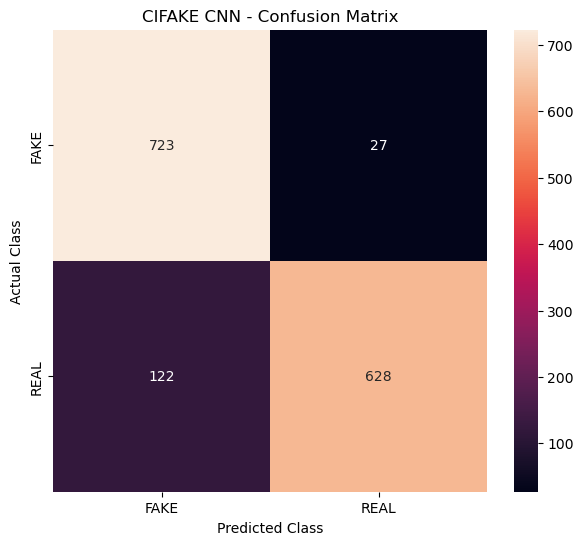

In [216]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CIFAKE CNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## Classification Report

In [219]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

        FAKE     0.8556    0.9640    0.9066       750
        REAL     0.9588    0.8373    0.8940       750

    accuracy                         0.9007      1500
   macro avg     0.9072    0.9007    0.9003      1500
weighted avg     0.9072    0.9007    0.9003      1500



## Storing Classification Metrics

In [222]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

metrics_df = pd.DataFrame(
    report_dict
).transpose()

metrics_df

,precision,recall,f1-score,support
FAKE,0.855621,0.964000,0.906583,750.000000
REAL,0.958779,0.837333,0.893950,750.000000
accuracy,0.900667,0.900667,0.900667,0.900667
macro avg,0.907200,0.900667,0.900267,1500.000000
weighted avg,0.907200,0.900667,0.900267,1500.000000


## Calculating Individual Confusion Matrix Values

In [225]:
TN, FP, FN, TP = cm.ravel()

print("True Negative  (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive  (TP):", TP)

True Negative  (TN): 723
False Positive (FP): 27
False Negative (FN): 122
True Positive  (TP): 628


## Calculating Metrics 

In [228]:
precision_real = TP / (TP + FP) if (TP + FP) != 0 else 0

recall_real = TP / (TP + FN) if (TP + FN) != 0 else 0

f1_real = (
    2 * precision_real * recall_real /
    (precision_real + recall_real)
    if (precision_real + recall_real) != 0
    else 0
)

accuracy_manual = (
    (TP + TN) /
    (TP + TN + FP + FN)
)

print("REAL Precision :", round(precision_real, 4))
print("REAL Recall    :", round(recall_real, 4))
print("REAL F1-score  :", round(f1_real, 4))
print("Accuracy       :", round(accuracy_manual, 4))

REAL Precision : 0.9588
REAL Recall    : 0.8373
REAL F1-score  : 0.894
Accuracy       : 0.9007


## Calculating Error Rate

In [231]:
total_predictions = len(y_true)

incorrect_predictions = np.sum(
    y_true != y_pred
)

correct_predictions = np.sum(
    y_true == y_pred
)

error_rate = (
    incorrect_predictions /
    total_predictions
)

print("Total predictions   :", total_predictions)
print("Correct predictions :", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

print(
    "\nError Rate:",
    round(error_rate * 100, 2),
    "%"
)

Total predictions   : 1500
Correct predictions : 1351
Incorrect predictions: 149

Error Rate: 9.93 %


## Finding MisClassified Images

In [234]:
test_results = test_df.copy()

test_results["actual_label"] = y_true
test_results["predicted_label"] = y_pred
test_results["probability_real"] = y_probability

test_results["actual_class"] = [
    class_names[label]
    for label in y_true
]

test_results["predicted_class"] = [
    class_names[label]
    for label in y_pred
]

misclassified = test_results[
    test_results["actual_label"] !=
    test_results["predicted_label"]
].copy()

print(
    "Total misclassified images:",
    len(misclassified)
)

display(misclassified.head())

Total misclassified images: 149


,filepath,class,label,actual_label,predicted_label,probability_real,actual_class,predicted_class
5435,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,1,1,0,0.002072,REAL,FAKE
5240,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0,0,1,0.549555,FAKE,REAL
8239,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,0,0,1,0.567469,FAKE,REAL
4579,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,1,1,0,0.215115,REAL,FAKE
9817,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,1,1,0,0.074860,REAL,FAKE


In [236]:
misclassification_percentage = (
    len(misclassified) /
    len(test_results)
) * 100

print(
    "Misclassification Percentage:",
    round(misclassification_percentage, 2),
    "%"
)

Misclassification Percentage: 9.93 %


### Displaying Misclassified Images 

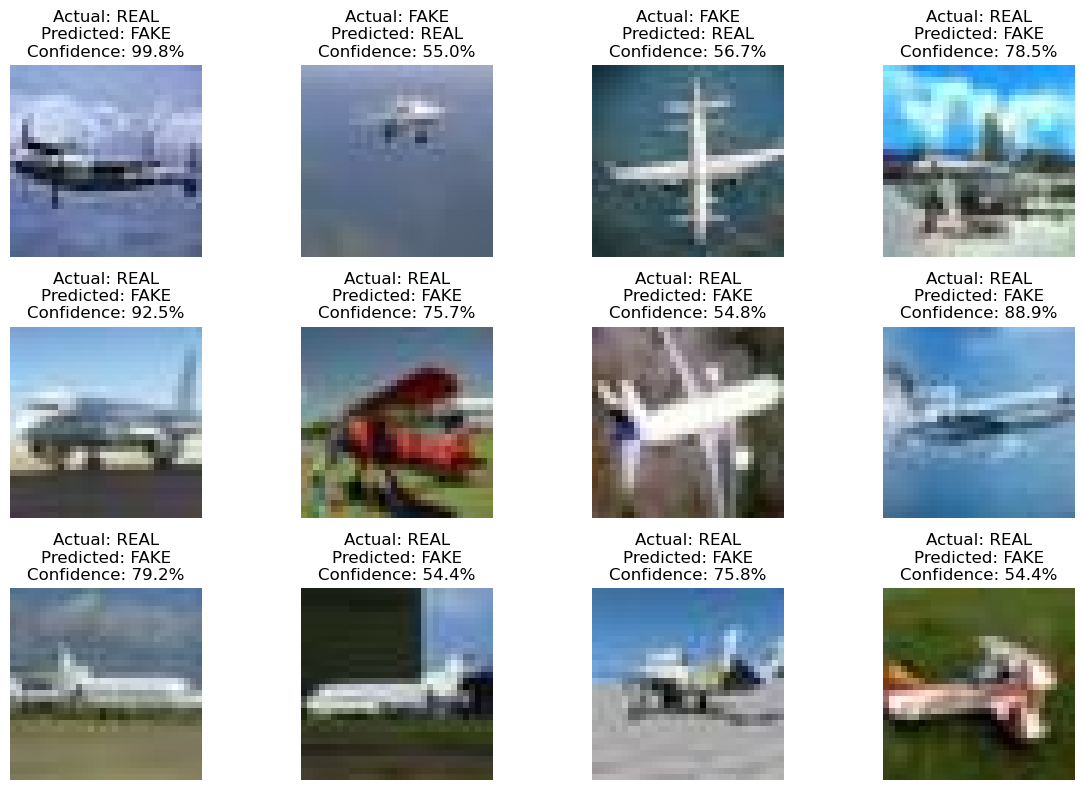

In [239]:
number_to_display = min(
    12,
    len(misclassified)
)

if number_to_display > 0:

    plt.figure(figsize=(12, 8))

    for i in range(number_to_display):

        row = misclassified.iloc[i]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        plt.subplot(3, 4, i + 1)

        plt.imshow(image)

        actual = row["actual_class"]
        predicted = row["predicted_class"]

        confidence = (
            row["probability_real"]
            if predicted == "REAL"
            else 1 - row["probability_real"]
        )

        plt.title(
            f"Actual: {actual}\n"
            f"Predicted: {predicted}\n"
            f"Confidence: {confidence * 100:.1f}%"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:

    print("No misclassified images found!")

## Displaying Correctly Classified Images

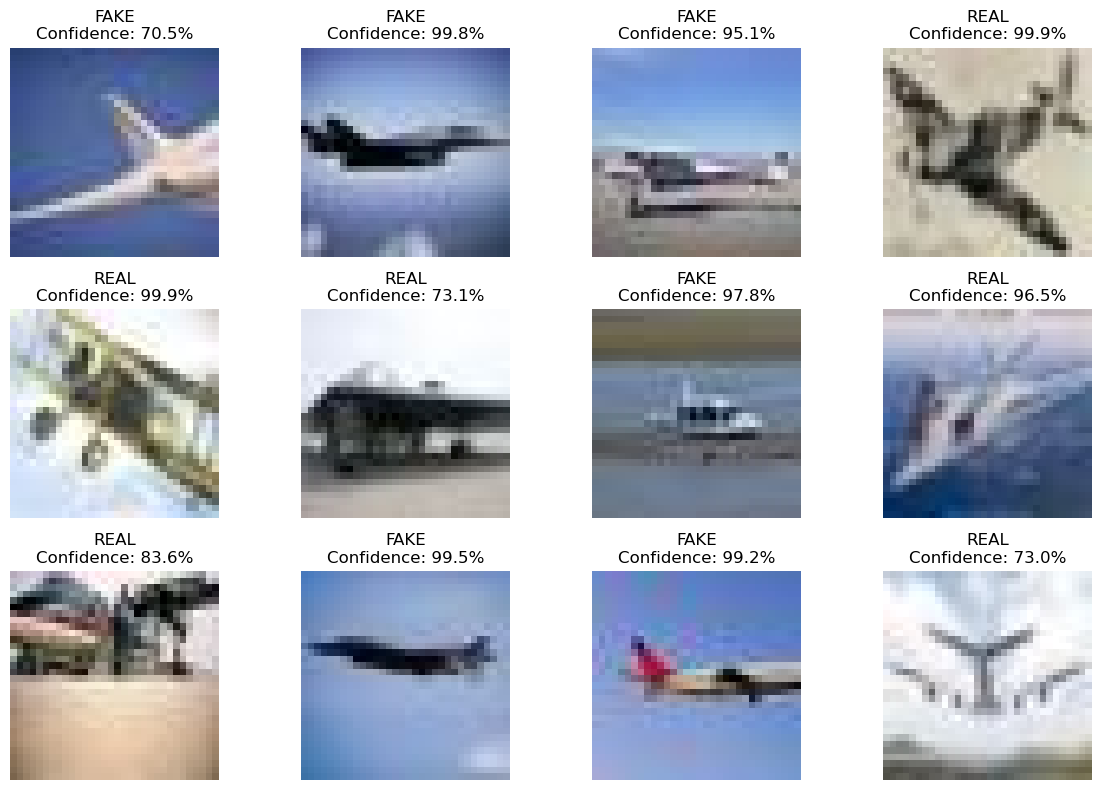

In [242]:
correctly_classified = test_results[
    test_results["actual_label"] ==
    test_results["predicted_label"]
].copy()

number_to_display = min(
    12,
    len(correctly_classified)
)

plt.figure(figsize=(12, 8))

for i in range(number_to_display):

    row = correctly_classified.iloc[i]

    image = Image.open(
        row["filepath"]
    ).convert("RGB")

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    actual = row["actual_class"]

    probability_real = row["probability_real"]

    confidence = (
        probability_real
        if actual == "REAL"
        else 1 - probability_real
    )

    plt.title(
        f"{actual}\n"
        f"Confidence: {confidence * 100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Analyzing Prediction Confidence

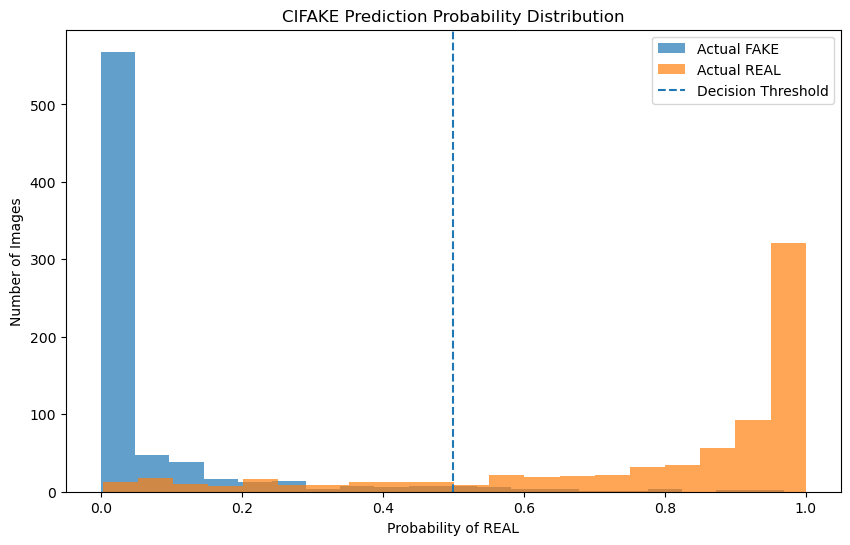

In [245]:
plt.figure(figsize=(10, 6))

plt.hist(
    y_probability[y_true == 0],
    bins=20,
    alpha=0.7,
    label="Actual FAKE"
)

plt.hist(
    y_probability[y_true == 1],
    bins=20,
    alpha=0.7,
    label="Actual REAL"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)

plt.title(
    "CIFAKE Prediction Probability Distribution"
)

plt.xlabel(
    "Probability of REAL"
)

plt.ylabel(
    "Number of Images"
)

plt.legend()

plt.show()

## Finding Low-Confidence Predictions

In [248]:
test_results["uncertainty"] = abs(
    test_results["probability_real"] - 0.5
)

low_confidence = test_results.sort_values(
    "uncertainty"
).head(12)

display(
    low_confidence[
        [
            "filepath",
            "actual_class",
            "predicted_class",
            "probability_real",
            "uncertainty"
        ]
    ]
)

,filepath,actual_class,predicted_class,probability_real,uncertainty
8450,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,REAL,0.500608,0.000608
9286,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,REAL,0.501178,0.001178
6891,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,FAKE,0.498052,0.001948
4755,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,FAKE,0.497446,0.002554
1363,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,FAKE,0.497395,0.002605
7757,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,FAKE,0.496392,0.003608
5513,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,FAKE,0.494981,0.005019
4884,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,FAKE,0.490846,0.009154
8762,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,REAL,FAKE,0.487471,0.012529
4994,D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Inter...,FAKE,REAL,0.512960,0.012960


## Displaying Low-Confidence Images

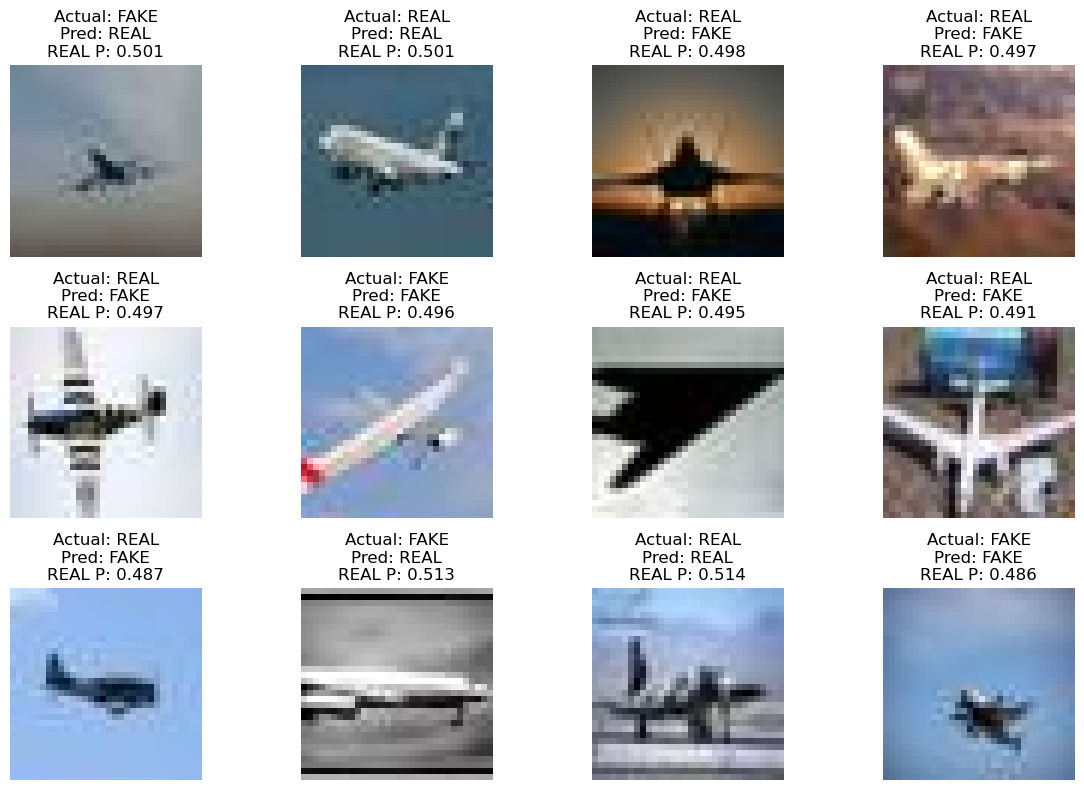

In [251]:
plt.figure(figsize=(12, 8))

for i in range(min(12, len(low_confidence))):

    row = low_confidence.iloc[i]

    image = Image.open(
        row["filepath"]
    ).convert("RGB")

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {row['actual_class']}\n"
        f"Pred: {row['predicted_class']}\n"
        f"REAL P: {row['probability_real']:.3f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Creating Final Evaluation Summary 

In [254]:
fake_precision = metrics_df.loc[
    "FAKE",
    "precision"
]

fake_recall = metrics_df.loc[
    "FAKE",
    "recall"
]

fake_f1 = metrics_df.loc[
    "FAKE",
    "f1-score"
]

real_precision = metrics_df.loc[
    "REAL",
    "precision"
]

real_recall = metrics_df.loc[
    "REAL",
    "recall"
]

real_f1 = metrics_df.loc[
    "REAL",
    "f1-score"
]

print("       CIFAKE CNN EVALUATION SUMMARY")

print(
    f"Test Accuracy       : "
    f"{evaluation_accuracy * 100:.2f}%"
)

print(
    f"Error Rate          : "
    f"{error_rate * 100:.2f}%"
)

print("\nFAKE CLASS")
print(
    f"Precision           : "
    f"{fake_precision:.4f}"
)
print(
    f"Recall              : "
    f"{fake_recall:.4f}"
)
print(
    f"F1-score            : "
    f"{fake_f1:.4f}"
)

print("\nREAL CLASS")
print(
    f"Precision           : "
    f"{real_precision:.4f}"
)
print(
    f"Recall              : "
    f"{real_recall:.4f}"
)
print(
    f"F1-score            : "
    f"{real_f1:.4f}"
)

print("\nCONFUSION MATRIX")
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

       CIFAKE CNN EVALUATION SUMMARY
Test Accuracy       : 90.07%
Error Rate          : 9.93%

FAKE CLASS
Precision           : 0.8556
Recall              : 0.9640
F1-score            : 0.9066

REAL CLASS
Precision           : 0.9588
Recall              : 0.8373
F1-score            : 0.8940

CONFUSION MATRIX
TN: 723
FP: 27
FN: 122
TP: 628


## Saving Test Results

In [257]:
results_file = "CIFAKE_Test_Predictions.csv"

test_results.to_csv(
    results_file,
    index=False
)

print(
    "Test prediction results saved to:",
    results_file
)

Test prediction results saved to: CIFAKE_Test_Predictions.csv


## Saving Confusion Matrix

In [260]:
cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual_FAKE",
        "Actual_REAL"
    ],
    columns=[
        "Predicted_FAKE",
        "Predicted_REAL"
    ]
)

cm_df.to_csv(
    "CIFAKE_Confusion_Matrix.csv"
)

print("Confusion matrix saved successfully!")

Confusion matrix saved successfully!


## Saving Classification Report 

In [263]:
metrics_df.to_csv(
    "CIFAKE_Classification_Report.csv"
)

print(
    "Classification report saved successfully!"
)

Classification report saved successfully!


# Explainable AI using Grad-CAM

## Importing Libraries

In [267]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from tensorflow.keras.models import Model
from PIL import Image

print("Grad-CAM libraries imported successfully!")

Grad-CAM libraries imported successfully!


## Finding the Last Convolution Layer

In [270]:
last_conv_layer = None

for layer in reversed(best_model.layers):

    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Last Convolution Layer:")
print(last_conv_layer)

Last Convolution Layer:
conv2d_2


## Displaying Model Layers

In [275]:
for i, layer in enumerate(best_model.layers):
    print(i, "->", layer.name, ":", layer.output.shape)

0 -> data_augmentation : (None, 32, 32, 3)
1 -> conv2d : (None, 32, 32, 32)
2 -> max_pooling2d : (None, 16, 16, 32)
3 -> conv2d_1 : (None, 16, 16, 64)
4 -> max_pooling2d_1 : (None, 8, 8, 64)
5 -> conv2d_2 : (None, 8, 8, 128)
6 -> max_pooling2d_2 : (None, 4, 4, 128)
7 -> flatten : (None, 2048)
8 -> dense : (None, 128)
9 -> dropout : (None, 128)
10 -> dense_1 : (None, 1)


## Loading a Test Image

In [278]:
sample_image = test_df.sample(
    1,
    random_state=42
).iloc[0]

image_path = sample_image["filepath"]
actual_label = sample_image["label"]

print("Image Path:")
print(image_path)

print("\nActual Class:")
print(class_names[actual_label])

Image Path:
D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Dataset\FAKE\4856.jpg

Actual Class:
FAKE


## Displaying Test Image

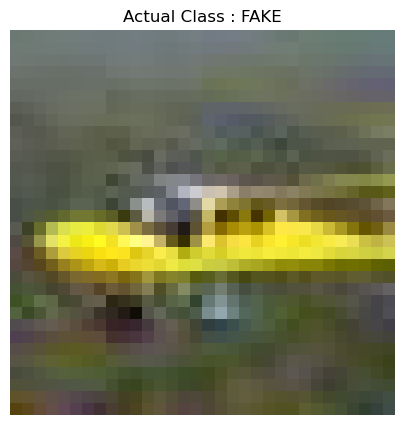

In [281]:
original_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(original_image)
plt.title(f"Actual Class : {class_names[actual_label]}")
plt.axis("off")
plt.show()

## Preprocessing Image for Grad-CAM

In [284]:
image = original_image.resize((IMG_WIDTH, IMG_HEIGHT))

image_array = np.array(image).astype("float32") / 255.0

input_image = np.expand_dims(image_array, axis=0)

print("Input Shape:", input_image.shape)

Input Shape: (1, 32, 32, 3)


## Predicting FAKE / REAL Image

In [287]:
prediction = best_model.predict(input_image, verbose=0)

probability_real = prediction[0][0]

if probability_real >= 0.5:
    predicted_label = 1
else:
    predicted_label = 0

predicted_class = class_names[predicted_label]

confidence = (
    probability_real
    if predicted_label == 1
    else 1 - probability_real
)

print("Predicted Class :", predicted_class)
print("Confidence      :", round(confidence*100,2), "%")

Predicted Class : FAKE
Confidence      : 96.93 %


## Building a Grad-CAM-compatible Functional model

In [310]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Input layer
gradcam_input = tf.keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    name="gradcam_input"
)

x = gradcam_input

# Dictionary to store outputs of important layers
gradcam_layer_outputs = {}

# Recreate the trained model layer-by-layer
for layer in best_model.layers:

    # Skip the data augmentation layer.
    # It is only needed during training.
    if layer.name == "data_augmentation":
        continue

    # Skip InputLayer if present
    if isinstance(layer, tf.keras.layers.InputLayer):
        continue

    # Create the same type of layer with the same configuration
    new_layer = layer.__class__.from_config(layer.get_config())

    # Apply the new layer
    x = new_layer(x)

    # Copy the trained weights
    if layer.get_weights():
        new_layer.set_weights(layer.get_weights())

    # Save the output of this layer
    gradcam_layer_outputs[layer.name] = x


# Create the new Functional model
gradcam_model = tf.keras.Model(
    inputs=gradcam_input,
    outputs=x,
    name="CIFAKE_GradCAM_Model"
)

print("Grad-CAM model created successfully!")
print()
print("Input shape :", gradcam_model.input_shape)
print("Output shape:", gradcam_model.output_shape)

Grad-CAM model created successfully!

Input shape : (None, 32, 32, 3)
Output shape: (None, 1)


## Verifying the last convolutional layer

In [313]:
last_conv_layer_name = "conv2d_2"

last_conv_output = gradcam_layer_outputs[last_conv_layer_name]

print("Last convolutional layer:", last_conv_layer_name)
print("Last convolutional output:", last_conv_output)

Last convolutional layer: conv2d_2
Last convolutional output: <KerasTensor shape=(None, 8, 8, 128), dtype=float32, sparse=False, name=keras_tensor_97>


## Creating the Grad-CAM model

In [316]:
grad_model = tf.keras.Model(
    inputs=gradcam_model.input,
    outputs=[
        last_conv_output,
        gradcam_model.output
    ]
)

print("Grad-CAM model created successfully.")
print("Input shape :", grad_model.input_shape)
print("Output count:", len(grad_model.outputs))

Grad-CAM model created successfully.
Input shape : (None, 32, 32, 3)
Output count: 2


## Testing the Grad-CAM model

In [319]:
conv_test, prediction_test = grad_model(
    input_image,
    training=False
)

print("Convolution output shape:", conv_test.shape)
print("Prediction output shape :", prediction_test.shape)
print("Prediction value        :", prediction_test.numpy())

Convolution output shape: (1, 8, 8, 128)
Prediction output shape : (1, 1)
Prediction value        : [[0.03068451]]


## Generating the Grad-CAM heatmap

In [322]:
with tf.GradientTape() as tape:

    # Get convolutional features and prediction
    conv_outputs, predictions = grad_model(
        input_image,
        training=False
    )

    probability_real = predictions[:, 0]

    # Grad-CAM should explain the predicted class
    if predicted_label == 1:
        class_score = probability_real
    else:
        class_score = 1.0 - probability_real


# Calculate gradients of the class score
# with respect to the convolutional feature maps
grads = tape.gradient(
    class_score,
    conv_outputs
)

# Average gradients across height and width
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

# Remove batch dimension
conv_outputs_single = conv_outputs[0]

# Weight each feature map by its importance
heatmap = tf.reduce_sum(
    conv_outputs_single * pooled_grads,
    axis=-1
)

# Remove negative values
heatmap = tf.maximum(heatmap, 0)

# Normalize between 0 and 1
heatmap = heatmap / (
    tf.reduce_max(heatmap) + 1e-8
)

heatmap = heatmap.numpy()

print("Grad-CAM heatmap generated successfully!")
print("Heatmap shape:", heatmap.shape)
print("Minimum value:", heatmap.min())
print("Maximum value:", heatmap.max())

Grad-CAM heatmap generated successfully!
Heatmap shape: (8, 8)
Minimum value: 0.0
Maximum value: 0.99999386


## Displaying the Grad-CAM heatmap

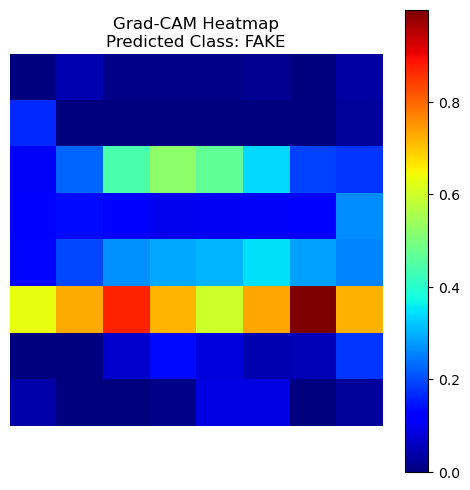

In [325]:
plt.figure(figsize=(6, 6))

plt.imshow(heatmap, cmap="jet")
plt.colorbar()

plt.title(
    f"Grad-CAM Heatmap\n"
    f"Predicted Class: {predicted_class}"
)

plt.axis("off")
plt.show()

## Creating heatmap overlay on the original image

In [328]:
# Resize heatmap to original image size
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (original_image.height, original_image.width)
).numpy().squeeze()

# Convert heatmap to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply a color map
heatmap_color = plt.cm.jet(
    heatmap_uint8
)[:, :, :3]

# Convert to 0-255 RGB
heatmap_color = np.uint8(
    heatmap_color * 255
)

# Convert original image to numpy
original_array = np.array(
    original_image
).astype(np.float32)

# Blend original image and heatmap
overlay = (
    0.6 * original_array +
    0.4 * heatmap_color
)

overlay = np.clip(
    overlay,
    0,
    255
).astype(np.uint8)

print("Grad-CAM overlay created successfully!")

Grad-CAM overlay created successfully!


## Displaying Original + Heatmap + Overlay

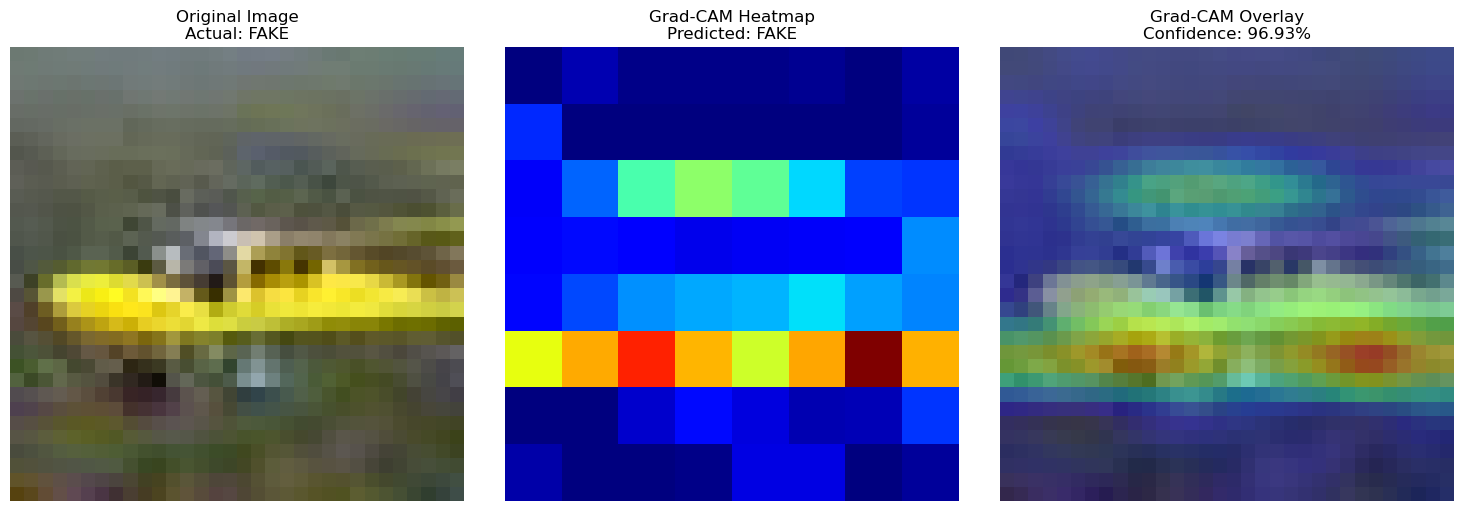

In [330]:
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title(
    f"Original Image\nActual: {class_names[actual_label]}"
)
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title(
    f"Grad-CAM Heatmap\nPredicted: {predicted_class}"
)
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM Overlay\nConfidence: {confidence * 100:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [333]:
print("Checking important variables...\n")

variables_to_check = [
    "df",
    "train_df",
    "val_df",
    "test_df",
    "history",
    "best_model",
    "test_results",
    "y_true",
    "y_pred",
    "y_probability",
    "cm"
]

for variable in variables_to_check:
    if variable in globals():
        print(f"✓ {variable} is available")
    else:
        print(f"✗ {variable} is NOT available")

Checking important variables...

✓ df is available
✓ train_df is available
✓ val_df is available
✓ test_df is available
✓ history is available
✓ best_model is available
✓ test_results is available
✓ y_true is available
✓ y_pred is available
✓ y_probability is available
✓ cm is available


In [341]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(y_true, y_pred)

final_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

total_test_images = len(y_true)
correct_predictions = int(np.sum(y_true == y_pred))
incorrect_predictions = int(np.sum(y_true != y_pred))

error_rate = incorrect_predictions / total_test_images


print("FINAL CIFAKE MODEL RESULTS")


print(f"Test Images           : {total_test_images}")
print(f"Correct Predictions   : {correct_predictions}")
print(f"Incorrect Predictions : {incorrect_predictions}")

print(f"\nAccuracy              : {final_accuracy * 100:.2f}%")
print(f"Precision             : {final_precision * 100:.2f}%")
print(f"Recall                : {final_recall * 100:.2f}%")
print(f"F1-Score              : {final_f1 * 100:.2f}%")
print(f"Error Rate            : {error_rate * 100:.2f}%")

FINAL CIFAKE MODEL RESULTS
Test Images           : 1500
Correct Predictions   : 1351
Incorrect Predictions : 149

Accuracy              : 90.07%
Precision             : 95.88%
Recall                : 83.73%
F1-Score              : 89.40%
Error Rate            : 9.93%


In [343]:

print(f"True Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives  (TP): {TP}")

True Negatives  (TN): 723
False Positives (FP): 27
False Negatives (FN): 122
True Positives  (TP): 628


In [347]:
history_dict = history.history

best_epoch = np.argmax(
    history_dict["val_accuracy"]
) + 1

best_val_accuracy = max(
    history_dict["val_accuracy"]
)

best_train_accuracy = history_dict["accuracy"][best_epoch - 1]


print("TRAINING SUMMARY")


print(f"Total epochs completed : {len(history_dict['loss'])}")
print(f"Best epoch             : {best_epoch}")
print(f"Training accuracy      : {best_train_accuracy * 100:.2f}%")
print(f"Best validation accuracy: {best_val_accuracy * 100:.2f}%")

TRAINING SUMMARY
Total epochs completed : 9
Best epoch             : 4
Training accuracy      : 88.51%
Best validation accuracy: 88.53%


In [349]:
final_results = pd.DataFrame({
    "Metric": [
        "Total Test Images",
        "Correct Predictions",
        "Incorrect Predictions",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Error Rate",
        "Best Epoch",
        "Best Validation Accuracy"
    ],
    "Value": [
        total_test_images,
        correct_predictions,
        incorrect_predictions,
        f"{final_accuracy * 100:.2f}%",
        f"{final_precision * 100:.2f}%",
        f"{final_recall * 100:.2f}%",
        f"{final_f1 * 100:.2f}%",
        f"{error_rate * 100:.2f}%",
        best_epoch,
        f"{best_val_accuracy * 100:.2f}%"
    ]
})

display(final_results)

,Metric,Value
0,Total Test Images,1500
1,Correct Predictions,1351
2,Incorrect Predictions,149
3,Accuracy,90.07%
4,Precision,95.88%
5,Recall,83.73%
6,F1-Score,89.40%
7,Error Rate,9.93%
8,Best Epoch,4
9,Best Validation Accuracy,88.53%


In [351]:
import os

project_folder = os.path.dirname(
    dataset_path
)

results_folder = os.path.join(
    project_folder,
    "Results"
)

os.makedirs(
    results_folder,
    exist_ok=True
)

print("Results folder:")
print(results_folder)

Results folder:
D:\Niraj Khankari\# INTERNSHIPS\Xtragrad Internship\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\CIFAKE Image Classification and Explainable Identification of AI-Generated Synthetic Images\Results


In [367]:
# ============================================================
# CIFAKE - FINAL OUTPUT SAVING (SHORT PATH FIX)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("CIFAKE - FINAL OUTPUT SAVING")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE SHORT RESULTS FOLDER
# ------------------------------------------------------------

results_folder = Path(r"D:\CIFAKE_Project_Results")

results_folder.mkdir(parents=True, exist_ok=True)

print("\nResults folder:")
print(results_folder)

print("\nFolder exists:")
print(results_folder.exists())

# ------------------------------------------------------------
# 2. TEST WRITE ACCESS
# ------------------------------------------------------------

test_file = results_folder / "write_test.txt"

try:
    with open(test_file, "w", encoding="utf-8") as f:
        f.write("CIFAKE output folder write test successful.")

    test_file.unlink()

    print("Folder is writable: True")

except Exception as e:
    print("Folder is writable: False")
    print("Error:", e)

# ------------------------------------------------------------
# 3. RECREATE FINAL TEST RESULTS
# ------------------------------------------------------------

# These variables should already exist from Phase 4:
# y_true
# y_probability
# test_results
# history
# best_model

y_true = np.asarray(y_true)
y_probability = np.asarray(y_probability)

# Binary prediction
y_pred = (y_probability >= 0.5).astype(int)

# ------------------------------------------------------------
# 4. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

TN, FP, FN, TP = cm.ravel()

print("\n" + "-" * 60)
print("CONFUSION MATRIX")
print("-" * 60)

print(cm)

print("\nTrue Negatives  (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives  (TP):", TP)

# ------------------------------------------------------------
# 5. FINAL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
error_rate = 1 - accuracy

# Best epoch from training history
if "val_accuracy" in history.history:
    best_epoch = int(
        np.argmax(history.history["val_accuracy"]) + 1
    )

    best_val_accuracy = float(
        np.max(history.history["val_accuracy"])
    )

else:
    best_epoch = None
    best_val_accuracy = None

print("\n" + "=" * 60)
print("FINAL CIFAKE MODEL RESULTS")
print("=" * 60)

print(f"Total Test Images            : {len(y_true)}")
print(f"Correct Predictions          : {int(np.sum(y_true == y_pred))}")
print(f"Incorrect Predictions        : {int(np.sum(y_true != y_pred))}")
print(f"Accuracy                     : {accuracy * 100:.2f}%")
print(f"Precision                    : {precision * 100:.2f}%")
print(f"Recall                       : {recall * 100:.2f}%")
print(f"F1-Score                     : {f1 * 100:.2f}%")
print(f"Error Rate                   : {error_rate * 100:.2f}%")

if best_epoch is not None:
    print(f"Best Epoch                   : {best_epoch}")
    print(f"Best Validation Accuracy     : {best_val_accuracy * 100:.2f}%")

# ------------------------------------------------------------
# 6. SAVE TRAINING ACCURACY
# ------------------------------------------------------------

training_accuracy_path = results_folder / "Training_Accuracy.png"

fig = plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CIFAKE CNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

fig.savefig(
    str(training_accuracy_path),
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("\n✓ Training accuracy saved")

# ------------------------------------------------------------
# 7. SAVE TRAINING LOSS
# ------------------------------------------------------------

training_loss_path = results_folder / "Training_Loss.png"

fig = plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CIFAKE CNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

fig.savefig(
    str(training_loss_path),
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("✓ Training loss saved")

# ------------------------------------------------------------
# 8. SAVE CONFUSION MATRIX IMAGE
# ------------------------------------------------------------

confusion_matrix_path = results_folder / "Confusion_Matrix.png"

fig = plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"]
)

plt.title("CIFAKE - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

fig.savefig(
    str(confusion_matrix_path),
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("✓ Confusion matrix image saved")

# ------------------------------------------------------------
# 9. SAVE CONFUSION MATRIX CSV
# ------------------------------------------------------------

confusion_matrix_csv = results_folder / "CIFAKE_Confusion_Matrix.csv"

cm_dataframe = pd.DataFrame(
    cm,
    index=["Actual_FAKE", "Actual_REAL"],
    columns=["Predicted_FAKE", "Predicted_REAL"]
)

cm_dataframe.to_csv(
    confusion_matrix_csv,
    index=True
)

print("✓ Confusion matrix CSV saved")

# ------------------------------------------------------------
# 10. SAVE CLASSIFICATION REPORT
# ------------------------------------------------------------

classification_report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["FAKE", "REAL"],
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

classification_report_path = (
    results_folder / "CIFAKE_Classification_Report.csv"
)

classification_report_df.to_csv(
    classification_report_path
)

print("✓ Classification report saved")

# ------------------------------------------------------------
# 11. SAVE TEST PREDICTIONS
# ------------------------------------------------------------

# Rebuild test_results if necessary
if "test_results" not in globals():

    test_results = pd.DataFrame({
        "actual_label": y_true,
        "predicted_label": y_pred,
        "probability_real": y_probability
    })

    test_results["actual_class"] = test_results[
        "actual_label"
    ].map({
        0: "FAKE",
        1: "REAL"
    })

    test_results["predicted_class"] = test_results[
        "predicted_label"
    ].map({
        0: "FAKE",
        1: "REAL"
    })

# Add uncertainty
test_results["uncertainty"] = abs(
    test_results["probability_real"] - 0.5
)

test_predictions_path = (
    results_folder / "CIFAKE_Test_Predictions.csv"
)

test_results.to_csv(
    test_predictions_path,
    index=False
)

print("✓ Test predictions CSV saved")

# ------------------------------------------------------------
# 12. SAVE FINAL RESULTS SUMMARY
# ------------------------------------------------------------

final_results = pd.DataFrame({
    "Metric": [
        "Total Test Images",
        "Correct Predictions",
        "Incorrect Predictions",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Error Rate",
        "Best Epoch",
        "Best Validation Accuracy"
    ],
    "Value": [
        len(y_true),
        int(np.sum(y_true == y_pred)),
        int(np.sum(y_true != y_pred)),
        int(TN),
        int(FP),
        int(FN),
        int(TP),
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{error_rate * 100:.2f}%",
        best_epoch,
        (
            f"{best_val_accuracy * 100:.2f}%"
            if best_val_accuracy is not None
            else "N/A"
        )
    ]
})

final_results_path = (
    results_folder / "CIFAKE_Final_Results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print("✓ Final results CSV saved")

# ------------------------------------------------------------
# 13. SAVE GRAD-CAM IMAGE IF AVAILABLE
# ------------------------------------------------------------

gradcam_path = results_folder / "GradCAM_Example.png"

if "overlay" in globals() and "original_image" in globals():

    fig = plt.figure(figsize=(8, 6))

    plt.imshow(overlay)
    plt.title(
        f"Grad-CAM - Predicted: {predicted_class} "
        f"({confidence * 100:.2f}%)"
    )
    plt.axis("off")

    fig.savefig(
        str(gradcam_path),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("✓ Grad-CAM image saved")

else:
    print("⚠ Grad-CAM variables not available - skipped")

# ------------------------------------------------------------
# 14. SAVE MODEL COPY
# ------------------------------------------------------------

model_copy_path = (
    results_folder / "CIFAKE_CNN_Final_Model.keras"
)

try:

    best_model.save(
        str(model_copy_path)
    )

    print("✓ Final model copied to Results folder")

except Exception as e:

    print("⚠ Model copy skipped:", e)

# ------------------------------------------------------------
# 15. VERIFY ALL FILES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("OUTPUT FILE VERIFICATION")
print("=" * 60)

expected_files = [
    training_accuracy_path,
    training_loss_path,
    confusion_matrix_path,
    confusion_matrix_csv,
    classification_report_path,
    test_predictions_path,
    final_results_path
]

if gradcam_path.exists():
    expected_files.append(gradcam_path)

if model_copy_path.exists():
    expected_files.append(model_copy_path)

all_files_exist = True

for file_path in expected_files:

    if file_path.exists():

        size_kb = file_path.stat().st_size / 1024

        print(
            f"✓ {file_path.name:<40} "
            f"{size_kb:.2f} KB"
        )

    else:

        print(
            f"✗ {file_path.name:<40} NOT FOUND"
        )

        all_files_exist = False

# ------------------------------------------------------------
# 16. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 60)

if all_files_exist:

    print("🎉 ALL CIFAKE OUTPUT FILES CREATED SUCCESSFULLY!")

else:

    print("⚠ Some output files were not created.")

print("=" * 60)

print("\nAll saved files are located at:")
print(results_folder)

print("\nFinal Accuracy :", f"{accuracy * 100:.2f}%")
print("Final F1-Score :", f"{f1 * 100:.2f}%")
print("Best Epoch     :", best_epoch)

CIFAKE - FINAL OUTPUT SAVING

Results folder:
D:\CIFAKE_Project_Results

Folder exists:
True
Folder is writable: True

------------------------------------------------------------
CONFUSION MATRIX
------------------------------------------------------------
[[723  27]
 [122 628]]

True Negatives  (TN): 723
False Positives (FP): 27
False Negatives (FN): 122
True Positives  (TP): 628

FINAL CIFAKE MODEL RESULTS
Total Test Images            : 1500
Correct Predictions          : 1351
Incorrect Predictions        : 149
Accuracy                     : 90.07%
Precision                    : 95.88%
Recall                       : 83.73%
F1-Score                     : 89.40%
Error Rate                   : 9.93%
Best Epoch                   : 4
Best Validation Accuracy     : 88.53%

✓ Training accuracy saved
✓ Training loss saved
✓ Confusion matrix image saved
✓ Confusion matrix CSV saved
✓ Classification report saved
✓ Test predictions CSV saved
✓ Final results CSV saved
✓ Grad-CAM image saved
✓ F